In [1]:
%run ../../../../Script/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [65]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

fitting new pseudotimes alignment without refitting SDA - to be removed

In [66]:
bdata = sc.read('../write/adata.soupx.dpt.h5ad')

Only considering the two last: ['.dpt', '.h5ad'].
Only considering the two last: ['.dpt', '.h5ad'].


In [67]:
adata.obs['dpt_cellalign'][bdata.obs_names] = round(bdata.obs['dpt_cellalign'],2)

In [68]:
adata = adata[bdata.obs_names].copy()

In [69]:
comp = ['4N','5N','12N','12P','19P','19N','26P','35N','35P',
       '37N','38N','37P','38P','42P','43P','44P','45N','49N','49P','50N','50P','52N','55N',
       '67P','72P','76P','78P','79P','79N','96N']

In [70]:
times = np.unique(adata.obs['dpt_cellalign'])

In [71]:
times

array([-0.  ,  0.02,  0.04,  0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,
        0.18,  0.2 ,  0.21,  0.22,  0.24,  0.25,  0.26,  0.27,  0.29,
        0.3 ,  0.31,  0.33,  0.35,  0.37,  0.39,  0.41,  0.43,  0.45,
        0.47,  0.49,  0.51,  0.53,  0.55,  0.56,  0.57,  0.59,  0.61,
        0.63,  0.65,  0.67,  0.69,  0.71,  0.73,  0.75,  0.76,  0.78,
        0.8 ,  0.82,  0.84,  0.86,  0.88,  0.9 ,  0.92,  0.94,  0.96,
        0.98,  1.  ])

In [72]:
df = pd.DataFrame(columns=times, index=comp)

In [80]:
for i in comp:
    num = i[:-1]
    sign = i[-1]
    val = adata.obs[f'SDA_cellscore_C{num}']
    #val = sklearn.preprocessing.scale( adata.obs[f'SDA_cellscore_C{num}'] )
    dpt = adata.obs['dpt_cellalign']
    for t in times:
        if(sign=='N'):
            scores = np.array( [np.abs(n) if n<0 else 0 for n in val], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)&(np.array(scores))>0] ) 
        else:
            scores = np.array( [ np.abs(n) if n>0 else 0 for n in val ], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)&(np.array(scores)>0)] )       
        if(np.isnan(mean_score)):
            df.loc[i,t] = 0
        else:
            df.loc[i,t] = mean_score

In [81]:
import sklearn

df2 = pd.DataFrame( sklearn.preprocessing.normalize(df, axis=0, norm='l1'),
                    columns=times, index=comp )

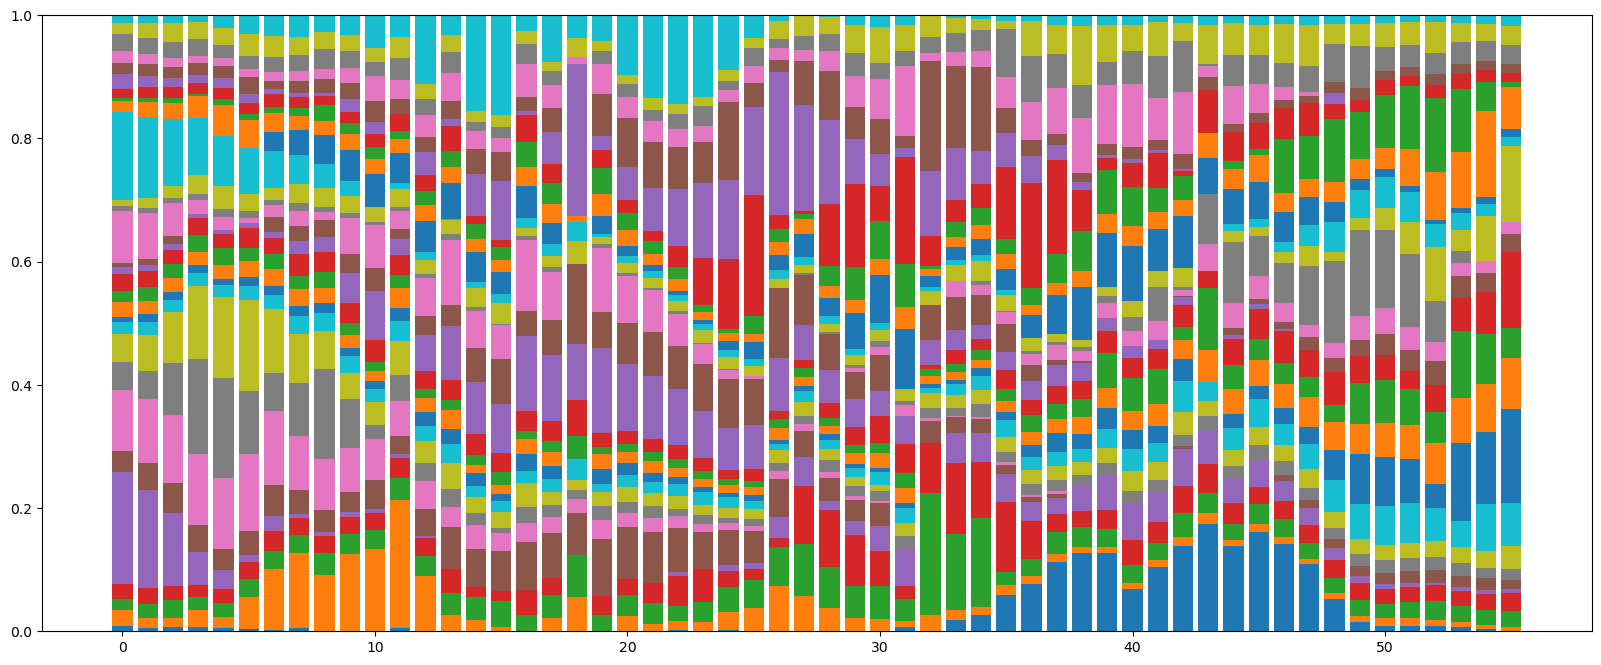

In [82]:
L = len(times)

x=np.zeros(L)

from matplotlib.colors import LinearSegmentedColormap
import colorsys

# Define N colors in RGB format
N = 32  # You can change this to any number you need

# Generate N distinct colors using the HSV color space
colors = []

for i in range(N):
    hue = i / N
    rgb_color = tuple( x for x in colorsys.hsv_to_rgb(hue, 1, .75) )
    colors.append(rgb_color)

#N = 32

#colors = plt.cm.tab20.colors[:N]

plt.rcParams['figure.figsize']=(20,8)

for i,col in zip(comp,colors):
       y = plt.bar(range(L), df2.loc[i, :], bottom=x)
       x = x + np.array(df2.loc[i, :])


    

In [83]:
assoc = dict()
assoc['SPG'] = ['19N','26P','35N','35P','79P','50N']
assoc['DNA_REPAIR'] = ['12N','12P']
assoc['MEIOSIS'] = ['5N','43P','44P','72P','76P']
assoc['SPC']=['67P','50P','79P','96N','79N']
assoc['ROUND_SPT'] = ['4N','49N','78P']
assoc['ELONG_SPT'] = ['49P','52N','55N','37N','37P','38N','38P','42P']

In [84]:
df3 = pd.DataFrame(index=assoc.keys(), columns=df.columns)

In [85]:
for i in assoc.keys():
    print(i)
    df3.loc[i, :] = df.loc[assoc[i],:].sum(axis=0)

SPG
DNA_REPAIR
MEIOSIS
SPC
ROUND_SPT
ELONG_SPT


In [86]:
df4 = pd.DataFrame( sklearn.preprocessing.normalize(df3, axis=0, norm='l1'),
                    index=df3.index, columns=df3.columns)

In [87]:
df3

,-0.00,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,...,0.82,0.84,0.86,0.88,0.90,0.92,0.94,0.96,0.98,1.00
SPG,6.75,6.8125,7.757812,9.585938,9.21875,8.109375,6.441406,5.820312,6.226562,4.574219,...,1.678955,1.97998,2.470581,2.424561,2.17749,2.06543,1.807861,1.814453,1.720459,1.703369
DNA_REPAIR,0.726562,0.810547,0.875,0.689453,0.789062,0.889648,0.947266,0.916992,0.987793,0.995605,...,0.858887,0.776367,0.78125,0.746094,0.658203,0.694336,0.734375,0.711426,0.750977,0.801758
MEIOSIS,1.475586,1.248047,1.164062,1.158081,1.0271,1.654053,2.328125,3.068359,2.677734,4.136719,...,0.567383,0.59668,1.001465,0.775269,0.878296,0.867554,0.848022,0.860413,0.789612,0.75415
SPC,1.261719,1.331055,1.491333,1.456665,1.479492,1.67749,2.195312,2.392578,2.355469,2.521484,...,3.166016,3.189453,2.410156,2.160156,1.791016,1.53125,1.603516,1.550781,1.585938,1.586914
ROUND_SPT,0.585938,0.488037,0.506348,0.494141,0.527344,0.436035,0.380127,0.530273,0.388428,0.536621,...,3.355469,3.015625,2.701172,2.150391,1.923828,1.789062,0.983398,0.373047,0.049866,0
ELONG_SPT,2.203125,2.509766,2.599609,3.150391,3.369141,3.185547,2.714844,3.113281,3.234375,3.050781,...,4.722656,4.609375,5.472656,5.890625,6.515625,6.90625,6.949219,8.820312,10.140625,9.960938


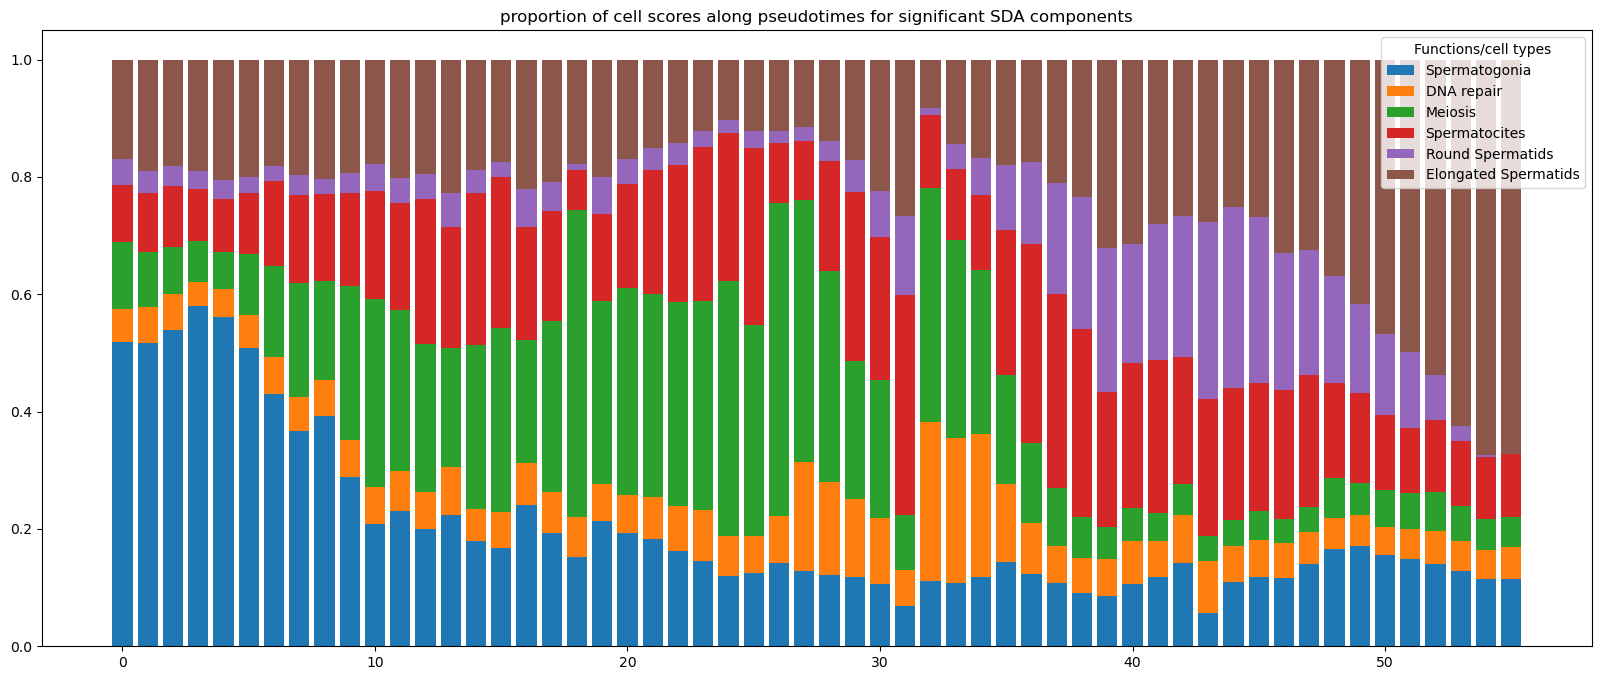

In [88]:
x = np.zeros(L)
for i,col in zip(assoc.keys(),colors):
       y = plt.bar(range(L), df4.loc[i, :], bottom=x)
       x = x + np.array(df4.loc[i, :])
plt.title("proportion of cell scores along pseudotimes for significant SDA components")
plt.legend(["Spermatogonia",
           "DNA repair", "Meiosis", "Spermatocites",
           "Round Spermatids", "Elongated Spermatids"], title="Functions/cell types")
plt.savefig("figures/timetable.svg", bbox_inches='tight', transparent=True )

In [21]:
times

array([-0.  ,  0.02,  0.04,  0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,
        0.18,  0.2 ,  0.21,  0.22,  0.24,  0.25,  0.26,  0.27,  0.29,
        0.3 ,  0.31,  0.33,  0.35,  0.37,  0.39,  0.41,  0.43,  0.45,
        0.47,  0.49,  0.51,  0.53,  0.55,  0.56,  0.57,  0.59,  0.61,
        0.63,  0.65,  0.67,  0.69,  0.71,  0.73,  0.75,  0.76,  0.78,
        0.8 ,  0.82,  0.84,  0.86,  0.88,  0.9 ,  0.92,  0.94,  0.96,
        0.98,  1.  ])

In [22]:
x_ticksnames = list()
for T in times:
    print(T)
    print( adata[adata.obs['dpt_cellalign']==T].obs['spermatogenesis_single'].value_counts() )

-0.0
SpermatogoniaA    241
SpermatogoniaB      3
Name: spermatogenesis_single, dtype: int64
0.02
SpermatogoniaA    267
SpermatogoniaB     17
Leptotene           2
Name: spermatogenesis_single, dtype: int64
0.04
SpermatogoniaA    159
SpermatogoniaB     50
Leptotene           3
Name: spermatogenesis_single, dtype: int64
0.06
SpermatogoniaB    35
SpermatogoniaA    28
Leptotene         27
Name: spermatogenesis_single, dtype: int64
0.08
Leptotene         31
SpermatogoniaB    30
SpermatogoniaA     2
Name: spermatogenesis_single, dtype: int64
0.1
SpermatogoniaB    66
Leptotene         27
Name: spermatogenesis_single, dtype: int64
0.12
SpermatogoniaB    134
Leptotene          40
Name: spermatogenesis_single, dtype: int64
0.14
SpermatogoniaB    62
Leptotene         50
Zygotene           6
Name: spermatogenesis_single, dtype: int64
0.16
SpermatogoniaB    172
Leptotene          58
Zygotene            8
Name: spermatogenesis_single, dtype: int64
0.18
SpermatogoniaB    134
Leptotene         126
Zyg

In [23]:
x_ticksnames = list()
for T in times:
    x_ticksnames.append( adata[adata.obs['dpt_cellalign']==T].obs['spermatogenesis_single'].value_counts().index[0] )

In [24]:
x_ticksnames

['SpermatogoniaA',
 'SpermatogoniaA',
 'SpermatogoniaA',
 'SpermatogoniaB',
 'Leptotene',
 'SpermatogoniaB',
 'SpermatogoniaB',
 'SpermatogoniaB',
 'SpermatogoniaB',
 'SpermatogoniaB',
 'Zygotene',
 'Leptotene',
 'Zygotene',
 'Zygotene',
 'Zygotene',
 'Pachytene',
 'Zygotene',
 'Zygotene',
 'Pachytene',
 'Zygotene',
 'Zygotene',
 'Pachytene',
 'Pachytene',
 'Pachytene',
 'Pachytene',
 'Diplotene',
 'Diplotene',
 'Diplotene',
 'Diplotene',
 'SpermatocitesII',
 'SpermatocitesII',
 'SpermatocitesII',
 'Diplotene',
 'Diplotene',
 'Diplotene',
 'Diplotene',
 'Diplotene',
 'SpermatocitesII',
 'SpermatocitesII',
 'SpermatocitesII',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Round_Spermatids',
 'Elong_Spermatids',
 'Elong_Spermatids',
 'Elong_Spermatids']

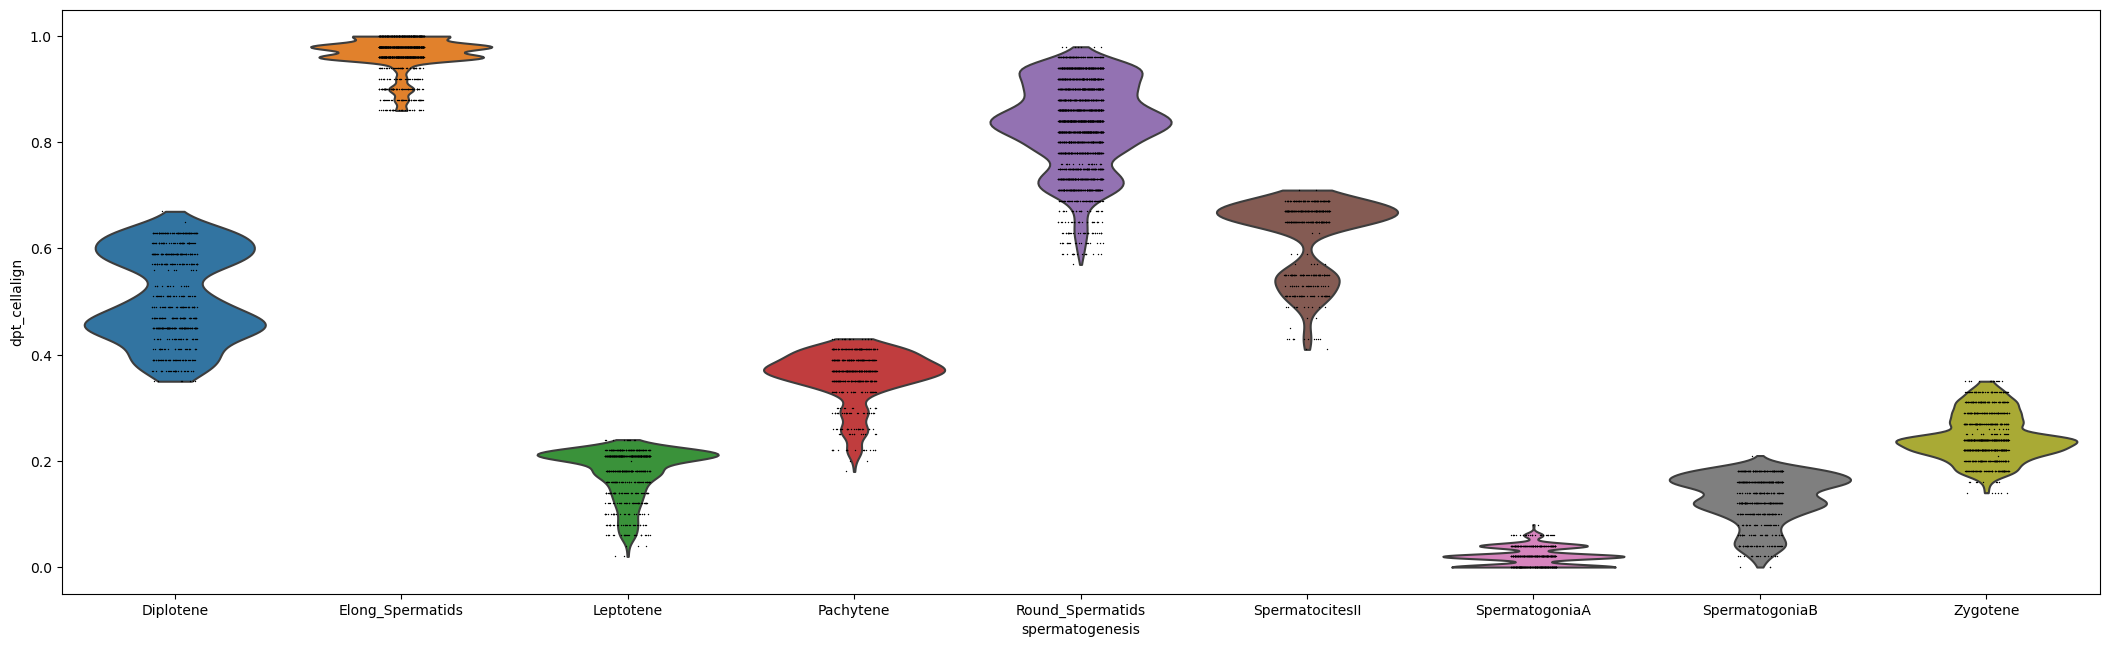

In [25]:
sc.pl.violin(adata, keys=['dpt_cellalign'], groupby='spermatogenesis')

## The same only for cells

In [26]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

fitting new pseudotimes alignment without refitting SDA - to be removed

In [27]:
bdata = sc.read('../write/adata.soupx.dpt.h5ad')

Only considering the two last: ['.dpt', '.h5ad'].
Only considering the two last: ['.dpt', '.h5ad'].


In [31]:
adata = adata[ adata.obs['batch']=='Cells' ]
bdata = bdata[ bdata.obs['batch']=='Cells' ]

In [32]:
adata.obs['dpt_cellalign'][bdata.obs_names] = round(bdata.obs['dpt_cellalign'],2)

In [33]:
adata = adata[bdata.obs_names].copy()

In [34]:
comp = ['4N','5N','12N','12P','19P','19N','26P','35N','35P',
       '37N','38N','37P','38P','42P','43P','44P','45N','49N','49P','50N','50P','52N','55N',
       '67P','72P','76P','78P','79P','79N','96N']

In [35]:
times = np.unique(adata.obs['dpt_cellalign'])

In [36]:
times

array([0.        , 0.02041039, 0.04059814, 0.06108714, 0.0816872 ,
       0.10298143, 0.12246241, 0.14259394, 0.16324517, 0.18409812,
       0.20353375, 0.22512576, 0.24611363, 0.26631927, 0.2858808 ,
       0.30882221, 0.32683796, 0.34846094, 0.36721775, 0.38518536,
       0.41361496, 0.4254989 , 0.44926631, 0.47318074, 0.48824525,
       0.51013821, 0.53025854, 0.54743236, 0.56932157, 0.59024262,
       0.61508775, 0.63527256, 0.65256375, 0.67397803, 0.69422102,
       0.71582645, 0.73426664, 0.75449377, 0.77611572, 0.79538476,
       0.81642532, 0.83649516, 0.85692245, 0.87757367, 0.89784282,
       0.91822571, 0.93879706, 0.95918602, 0.97985238, 1.        ])

In [37]:
df = pd.DataFrame(columns=times, index=comp)

In [38]:
for i in comp:
    num = i[:-1]
    sign = i[-1]
    val = adata.obs[f'SDA_cellscore_C{num}']
    #val = sklearn.preprocessing.scale( adata.obs[f'SDA_cellscore_C{num}'] )
    dpt = adata.obs['dpt_cellalign']
    for t in times:
        if(sign=='N'):
            scores = np.array( [np.abs(n) if n<0 else 0 for n in val], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)] ) 
        else:
            scores = np.array( [ np.abs(n) if n>0 else 0 for n in val ], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)] )       
        df.loc[i,t] = mean_score

In [39]:
import sklearn

df2 = pd.DataFrame( sklearn.preprocessing.normalize(df, axis=0, norm='l1'),
                    columns=times, index=comp )

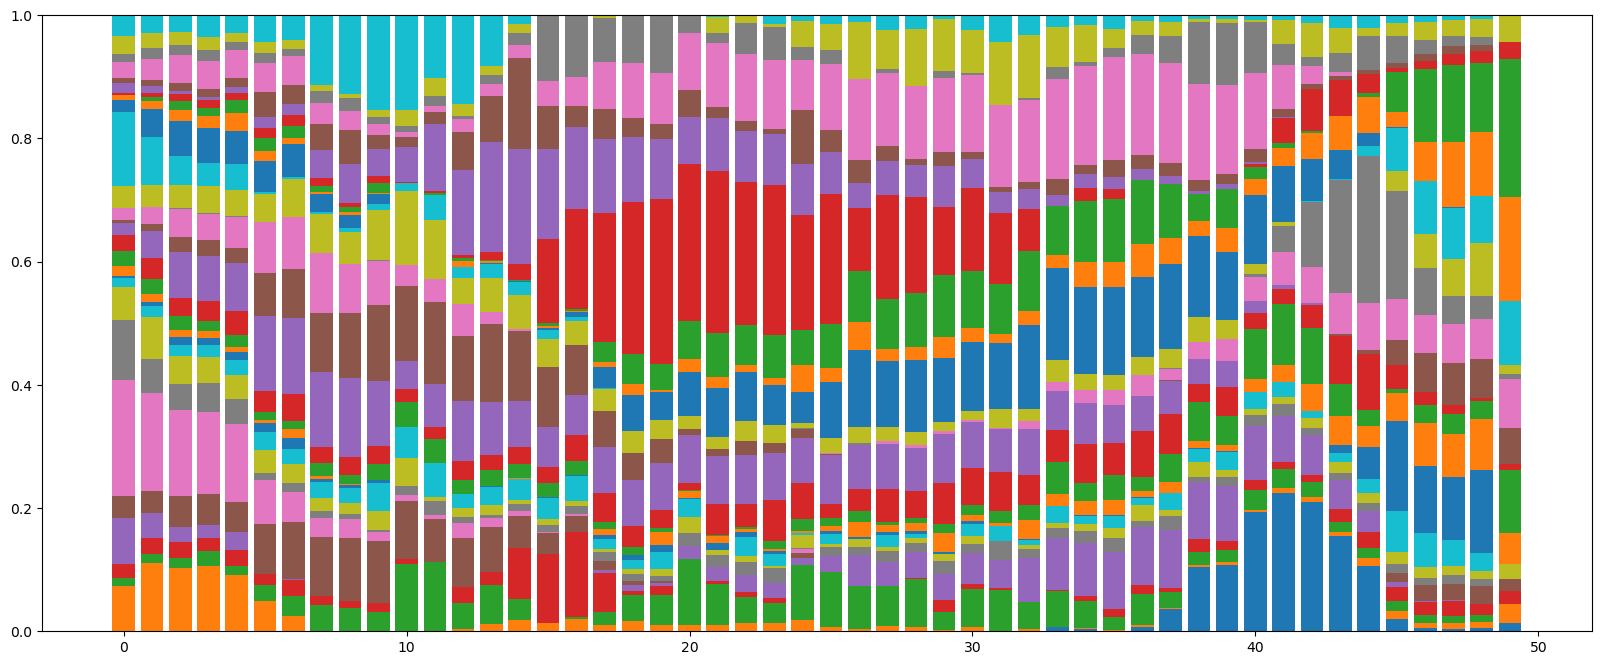

In [40]:
L = len(times)

x=np.zeros(L)

from matplotlib.colors import LinearSegmentedColormap
import colorsys

# Define N colors in RGB format
N = 32  # You can change this to any number you need

# Generate N distinct colors using the HSV color space
colors = []

for i in range(N):
    hue = i / N
    rgb_color = tuple( x for x in colorsys.hsv_to_rgb(hue, 1, .75) )
    colors.append(rgb_color)

#N = 32

#colors = plt.cm.tab20.colors[:N]

plt.rcParams['figure.figsize']=(20,8)

for i,col in zip(comp,colors):
       y = plt.bar(range(L), df2.loc[i, :], bottom=x)
       x = x + np.array(df2.loc[i, :])


    

In [41]:
assoc = dict()
assoc['SPG'] = ['19N','26P','35N','35P','79P','50N']
assoc['DNA_REPAIR'] = ['12N','12P']
assoc['MEIOSIS'] = ['5N','43P','44P','72P','76P']
assoc['SPC']=['67P','50P','79P','96N','79N']
assoc['ROUND_SPT'] = ['4N','49N','78P']
assoc['ELONG_SPT'] = ['49P','52N','55N','37N','37P','38N','38P','42P']

In [42]:
df3 = pd.DataFrame(index=assoc.keys(), columns=df.columns)

In [43]:
for i in assoc.keys():
    print(i)
    df3.loc[i, :] = df.loc[assoc[i],:].sum(axis=0)

SPG
DNA_REPAIR
MEIOSIS
SPC
ROUND_SPT
ELONG_SPT


In [44]:
df4 = pd.DataFrame( sklearn.preprocessing.normalize(df3, axis=0, norm='l1'),
                    index=df3.index, columns=df3.columns)

In [45]:
df3

,0.000000,0.020410,0.040598,0.061087,0.081687,0.102981,0.122462,0.142594,0.163245,0.184098,...,0.816425,0.836495,0.856922,0.877574,0.897843,0.918226,0.938797,0.959186,0.979852,1.000000
SPG,5.539062,4.582031,3.664062,3.414062,3.458984,2.595703,2.195312,2.240234,2.53125,2.066406,...,1.253906,0.728516,0.497314,0.723145,1.095703,1.749023,1.779297,1.644531,1.59082,1.890625
DNA_REPAIR,0.399902,0.459229,0.458984,0.47583,0.457031,0.516602,0.640625,0.702148,0.667969,0.553223,...,0.539551,0.476562,0.414551,0.425781,0.451172,0.42627,0.374023,0.386475,0.318359,0.261719
MEIOSIS,1.317383,2.072266,2.359375,2.341797,2.40625,3.498047,3.025391,3.775391,4.84375,3.5625,...,0.563477,0.341797,0.229736,0.181152,0.269775,0.651367,0.917969,0.979004,0.936035,1.137695
SPC,1.081055,1.37207,1.407227,1.501953,1.352539,1.682617,1.480469,2.267578,2.482422,2.462891,...,2.384766,2.390625,2.5625,2.259766,1.538086,0.937012,0.836914,0.713379,0.75293,0.900879
ROUND_SPT,0.289551,0.390381,0.503418,0.492188,0.516602,0.561523,0.518066,0.417969,0.432861,0.225464,...,3.652344,3.78125,4.027344,3.951172,3.71875,2.099609,0.887695,0.531738,0.463867,0.261475
ELONG_SPT,1.412109,1.670898,1.758789,1.776367,2.152344,2.091797,2.248047,1.972656,1.919922,2.490234,...,2.490234,2.435547,2.695312,2.982422,3.130859,4.558594,5.691406,5.929688,6.554688,7.269531


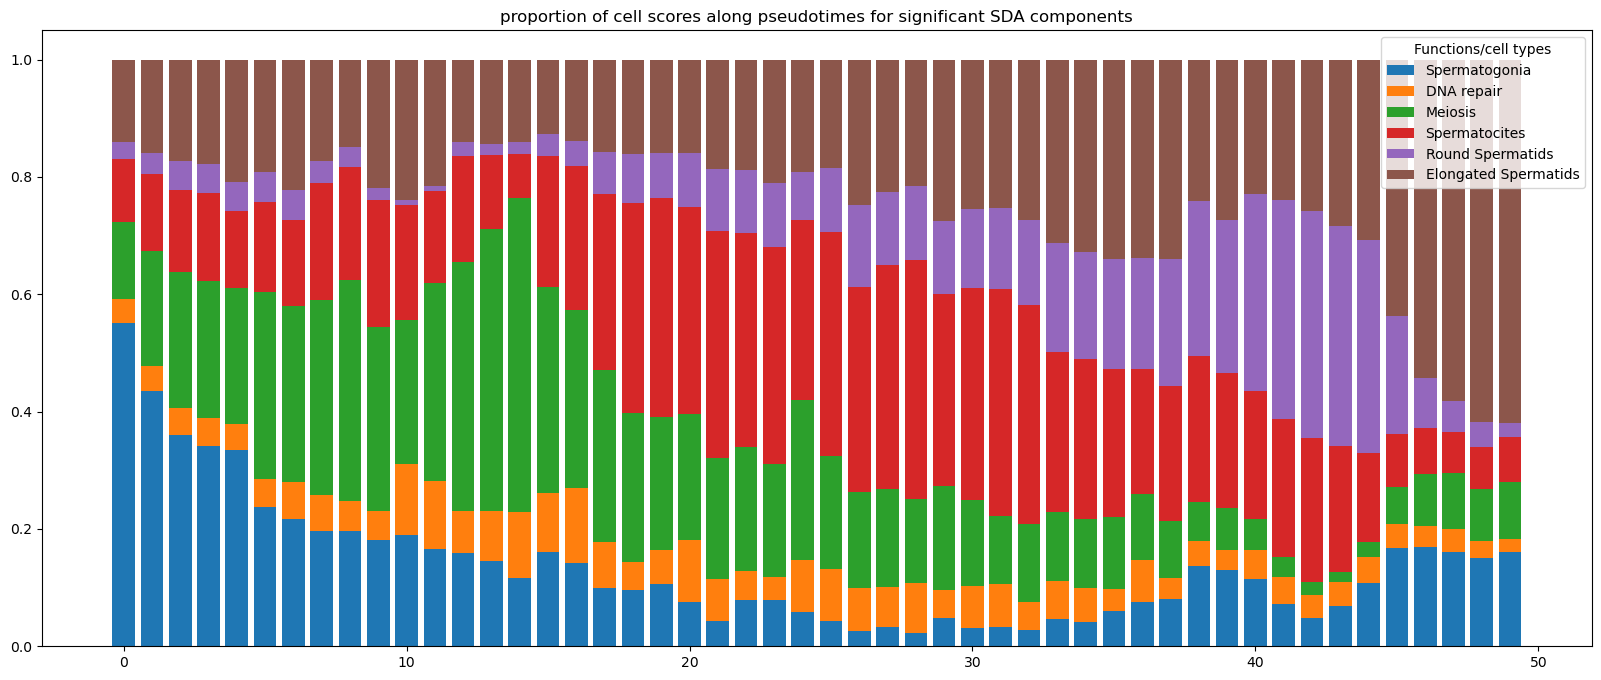

In [46]:
x = np.zeros(L)
for i,col in zip(assoc.keys(),colors):
       y = plt.bar(range(L), df4.loc[i, :], bottom=x)
       x = x + np.array(df4.loc[i, :])
plt.title("proportion of cell scores along pseudotimes for significant SDA components")
plt.legend(["Spermatogonia",
           "DNA repair", "Meiosis", "Spermatocites",
           "Round Spermatids", "Elongated Spermatids"], title="Functions/cell types")
plt.savefig("figures/timetable.svg", bbox_inches='tight', transparent=True )

## The same only for nuclei

In [47]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

fitting new pseudotimes alignment without refitting SDA - to be removed

In [48]:
bdata = sc.read('../write/adata.soupx.dpt.h5ad')

Only considering the two last: ['.dpt', '.h5ad'].
Only considering the two last: ['.dpt', '.h5ad'].


In [49]:
adata = adata[ adata.obs['batch']=='Nuclei' ]
bdata = bdata[ bdata.obs['batch']=='Nuclei' ]

In [50]:
adata.obs['dpt_cellalign'][bdata.obs_names] = round(bdata.obs['dpt_cellalign'],2)

In [51]:
adata = adata[bdata.obs_names].copy()

In [52]:
comp = ['4N','5N','12N','12P','19P','19N','26P','35N','35P',
       '37N','38N','37P','38P','42P','43P','44P','45N','49N','49P','50N','50P','52N','55N',
       '67P','72P','76P','78P','79P','79N','96N']

In [53]:
times = np.unique(adata.obs['dpt_cellalign'])

In [54]:
times

array([0.        , 0.02041374, 0.04083947, 0.06122234, 0.08154762,
       0.10227784, 0.12242953, 0.14287429, 0.16324182, 0.18366039,
       0.20413642, 0.22430851, 0.24508613, 0.26546195, 0.28550991,
       0.30609581, 0.32764241, 0.34722704, 0.36721334, 0.38775167,
       0.40875593, 0.42877015, 0.44820398, 0.47033247, 0.49029976,
       0.51023215, 0.53059042, 0.55108732, 0.57121658, 0.59217042,
       0.61205149, 0.63256234, 0.65316385, 0.67335838, 0.69387949,
       0.71427697, 0.73468041, 0.75510764, 0.77545834, 0.79588604,
       0.81662279, 0.83677733, 0.85741758, 0.87745035, 0.89793402,
       0.91834247, 0.93876457, 0.95917803, 0.97967976, 1.        ])

In [55]:
df = pd.DataFrame(columns=times, index=comp)

In [56]:
for i in comp:
    num = i[:-1]
    sign = i[-1]
    val = adata.obs[f'SDA_cellscore_C{num}']
    #val = sklearn.preprocessing.scale( adata.obs[f'SDA_cellscore_C{num}'] )
    dpt = adata.obs['dpt_cellalign']
    for t in times:
        if(sign=='N'):
            scores = np.array( [np.abs(n) if n<0 else 0 for n in val], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)] ) 
        else:
            scores = np.array( [ np.abs(n) if n>0 else 0 for n in val ], dtype='float16' )
            mean_score = np.mean( np.array(scores)[(dpt==t)] )       
        df.loc[i,t] = mean_score

In [57]:
import sklearn

df2 = pd.DataFrame( sklearn.preprocessing.normalize(df, axis=0, norm='l1'),
                    columns=times, index=comp )

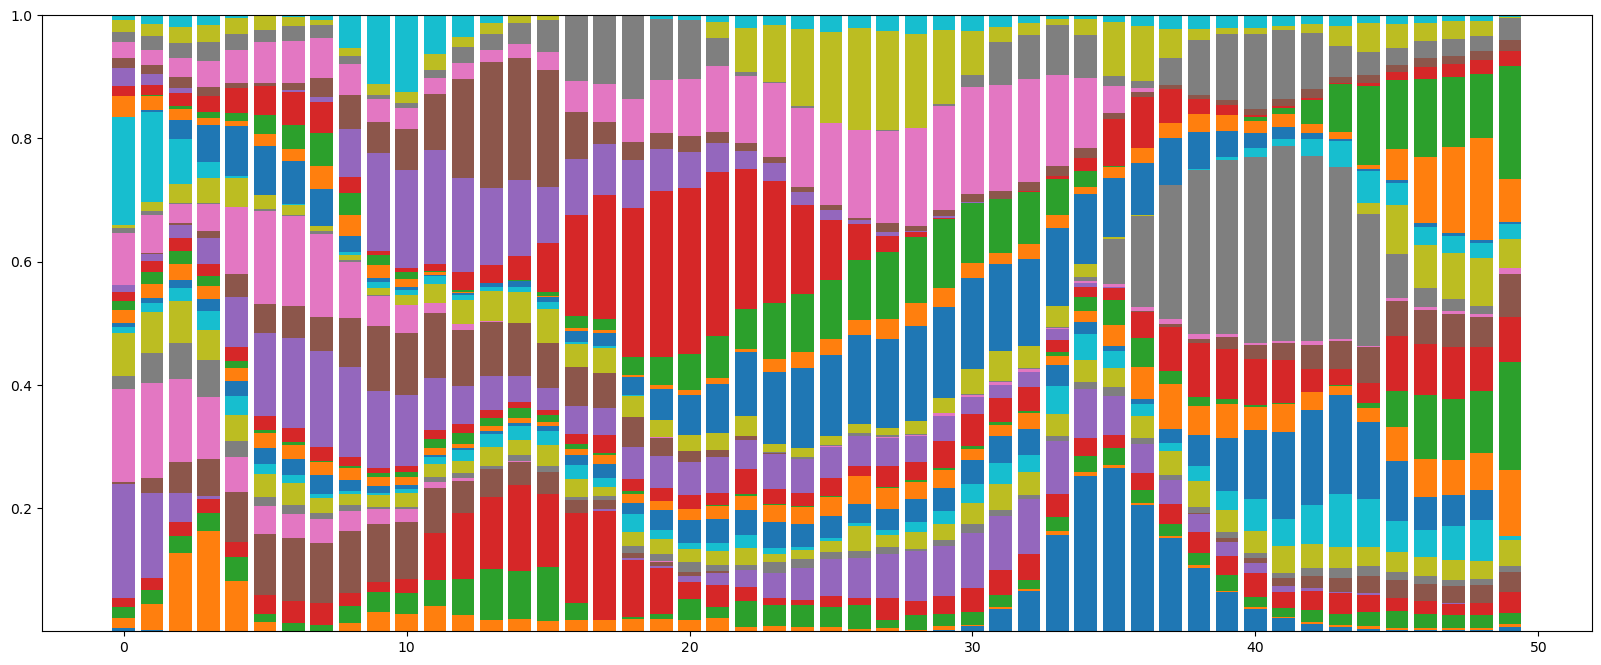

In [58]:
L = len(times)

x=np.zeros(L)

from matplotlib.colors import LinearSegmentedColormap
import colorsys

# Define N colors in RGB format
N = 32  # You can change this to any number you need

# Generate N distinct colors using the HSV color space
colors = []

for i in range(N):
    hue = i / N
    rgb_color = tuple( x for x in colorsys.hsv_to_rgb(hue, 1, .75) )
    colors.append(rgb_color)

#N = 32

#colors = plt.cm.tab20.colors[:N]

plt.rcParams['figure.figsize']=(20,8)

for i,col in zip(comp,colors):
       y = plt.bar(range(L), df2.loc[i, :], bottom=x)
       x = x + np.array(df2.loc[i, :])


    

In [59]:
assoc = dict()
assoc['SPG'] = ['19N','26P','35N','35P','79P','50N']
assoc['DNA_REPAIR'] = ['12N','12P']
assoc['MEIOSIS'] = ['5N','43P','44P','72P','76P']
assoc['SPC']=['67P','50P','79P','96N','79N']
assoc['ROUND_SPT'] = ['4N','49N','78P']
assoc['ELONG_SPT'] = ['49P','52N','55N','37N','37P','38N','38P','42P']

In [60]:
df3 = pd.DataFrame(index=assoc.keys(), columns=df.columns)

In [61]:
for i in assoc.keys():
    print(i)
    df3.loc[i, :] = df.loc[assoc[i],:].sum(axis=0)

SPG
DNA_REPAIR
MEIOSIS
SPC
ROUND_SPT
ELONG_SPT


In [62]:
df4 = pd.DataFrame( sklearn.preprocessing.normalize(df3, axis=0, norm='l1'),
                    index=df3.index, columns=df3.columns)

In [63]:
df3

,0.000000,0.020414,0.040839,0.061222,0.081548,0.102278,0.122430,0.142874,0.163242,0.183660,...,0.816623,0.836777,0.857418,0.877450,0.897934,0.918342,0.938765,0.959178,0.979680,1.000000
SPG,5.261719,4.824219,3.820312,2.855469,2.121094,2.152344,2.345703,2.378906,2.384766,2.189453,...,1.335938,1.328125,1.34668,1.154297,1.148438,1.0625,1.061523,1.087891,1.076172,1.15625
DNA_REPAIR,0.395996,0.439941,0.472656,0.460205,0.574219,0.445312,0.535156,0.553223,0.639648,0.681641,...,0.395508,0.293701,0.35498,0.362793,0.353027,0.379639,0.359375,0.344727,0.362305,0.416992
MEIOSIS,0.885742,0.895508,1.631836,2.033203,1.880859,2.001953,2.302734,3.125,5.023438,6.59375,...,0.248779,0.278809,0.402344,0.419434,0.512695,0.569336,0.605469,0.588867,0.62207,0.740234
SPC,0.714844,0.77832,1.139648,1.412109,1.609375,1.689453,1.804688,1.802734,1.753906,2.080078,...,1.27832,1.113281,0.929199,0.748535,0.731445,0.756348,0.780273,0.783691,0.78125,0.540527
ROUND_SPT,0.467773,0.334473,0.31958,0.383301,0.484863,0.678711,0.759766,0.862793,0.716797,0.527344,...,2.386719,2.376953,2.199219,2.007812,1.523438,0.570801,0.272217,0.176392,0.125732,0.052795
ELONG_SPT,1.276367,1.288086,1.447266,1.473633,1.603516,1.682617,1.814453,2.273438,1.891602,1.337891,...,2.160156,2.351562,2.375,2.660156,2.929688,4.652344,5.394531,5.773438,6.328125,5.320312


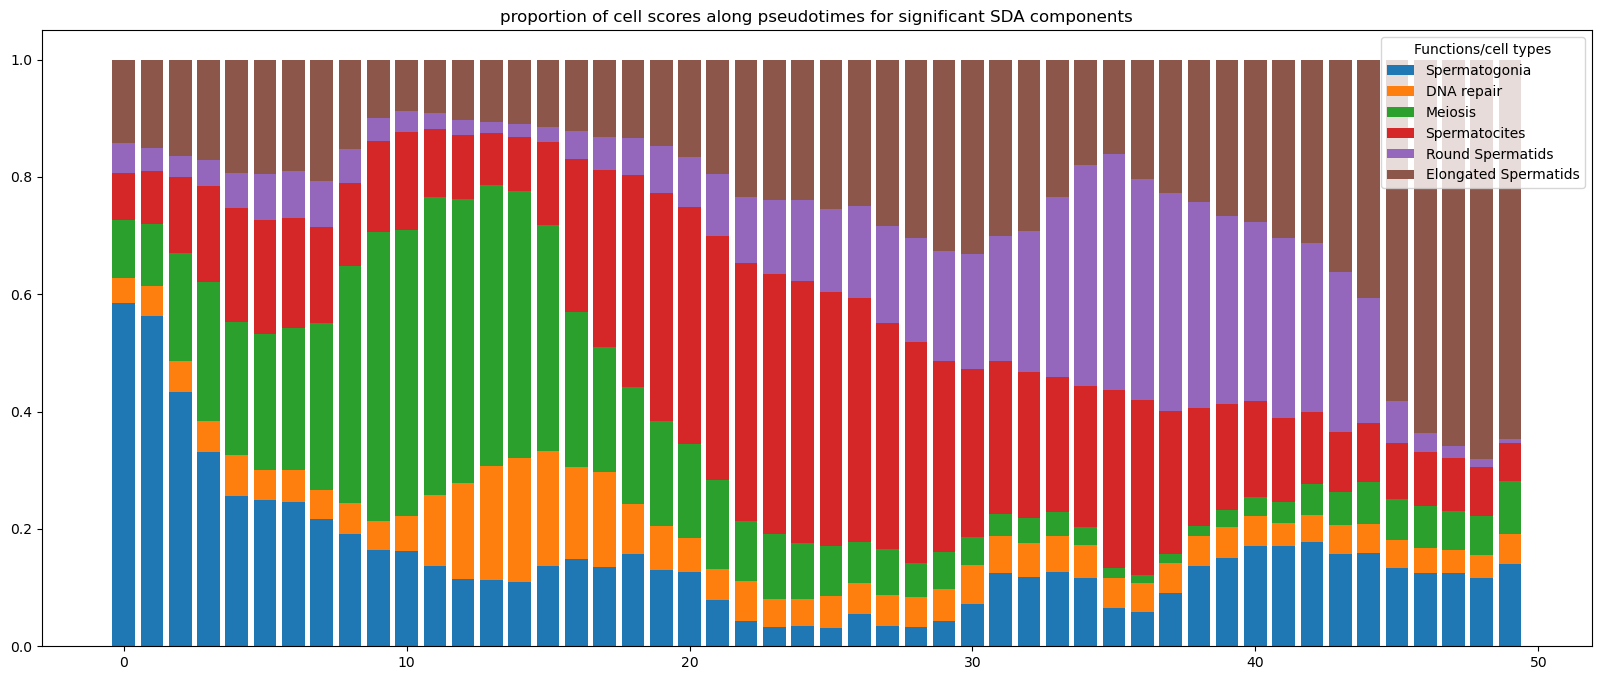

In [64]:
x = np.zeros(L)
for i,col in zip(assoc.keys(),colors):
       y = plt.bar(range(L), df4.loc[i, :], bottom=x)
       x = x + np.array(df4.loc[i, :])
plt.title("proportion of cell scores along pseudotimes for significant SDA components")
plt.legend(["Spermatogonia",
           "DNA repair", "Meiosis", "Spermatocites",
           "Round Spermatids", "Elongated Spermatids"], title="Functions/cell types")
plt.savefig("figures/timetable.svg", bbox_inches='tight', transparent=True )